Projeto Final - Mídulo 1 - SCTEC

# Fase 2: Limpeza e Tratamento de Dados (Data Prep)

Identifique e remova as linhas duplicadas.

Identifique dados ausentes e aplique a imputação por Média ou Mediana, justificando textualmente a escolha com base na distribuição dos dados.

Gere gráficos do tipo boxplot para identificar a presença de outliers nas variáveis explicativas.


In [1]:
# Configuração inicial para todos os notebooks

# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração do visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("n\=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===")

<>:16: SyntaxWarning: "\=" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\="? A raw string is also an option.
<>:16: SyntaxWarning: "\=" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\="? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_13800\217933160.py:16: SyntaxWarning: "\=" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\="? A raw string is also an option.
  print("n\=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===")


n\=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===


In [2]:
# Carregando os dados do dataset

df = pd.read_csv("../data/raw/manutencao_preditiva.csv", sep=",")
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [3]:
# Identificando duplicados

df.duplicated().sum()

np.int64(0)

Análise

Não há duplicados

In [4]:
# Identificando valores ausentes

df.isna().sum()

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

In [5]:
# Analisando as colunas com valores ausentes

colunas = ["temperatura_ar_k", "temperatura_processo_k", "velocidade_rotacao_rpm", "torque_nm"]


resumo = pd.DataFrame({
    "Valores ausentes": df[colunas].isnull().sum(),
    "Mínimo": df[colunas].min(),
    "Máximo": df[colunas].max(),
    "Média": df[colunas].mean(),
    "Mediana": df[colunas].median(),
    "Desvio padrão": df[colunas].std()
    })

resumo

,Valores ausentes,Mínimo,Máximo,Média,Mediana,Desvio padrão
temperatura_ar_k,500,295.3,304.5,300.002158,300.1,2.001689
temperatura_processo_k,500,305.7,313.8,310.000895,310.1,1.486432
velocidade_rotacao_rpm,500,1168.0,2886.0,1539.245263,1504.0,180.273589
torque_nm,500,3.8,76.6,39.974168,40.1,9.995453


Análise

Foram identificados 500 valores ausentes nas variáveis temperatura do ar, temperatura do processo, velocidade de rotação e torque. Os valores ausentes representam, portanto, cerca de 5% do total de registros em cada variável. Para evitar a redução do conjunto de dados, os dados ausentes podem ser substituídos pela média ou pela mediana. Neste projeto, optou-se pela imputação da mediana, baseada na análise estatística descritiva, que mostrou que as variáveis de temperatura apresentam média e mediana praticamente iguais, mas as variáveis de velocidade de rotação e torque apresentaram uma diferença um pouco maior entre média e mediana, sugerindo maior dispersão dos dados e possível infuência de outliers.
A mediana é menos afetada pela presença destes valores extremos, preserva melhor as características originais dos dados e reduz o risco de distorções do modelo.

In [6]:
# Tratando valores ausentes

# Fazendo uma cópia do banco de dados para tratamento
df_tratado = df.copy()
           
# Substituindo os valores ausentes destas colunas pela mediana
for coluna in colunas:
    df_tratado[coluna] = df_tratado[coluna].fillna(df_tratado[coluna].median())

# Salvando a base de dados tratada
df_tratado.to_csv("../data/processed/manutencao_preditiva_tratado.csv", index=False)

In [7]:
# Checando substituição dos nulos

df_tratado.isna().sum()

udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64

Grafico salvo em:../outputs/graficos\02_data_prep\01_boxplot_todas.png


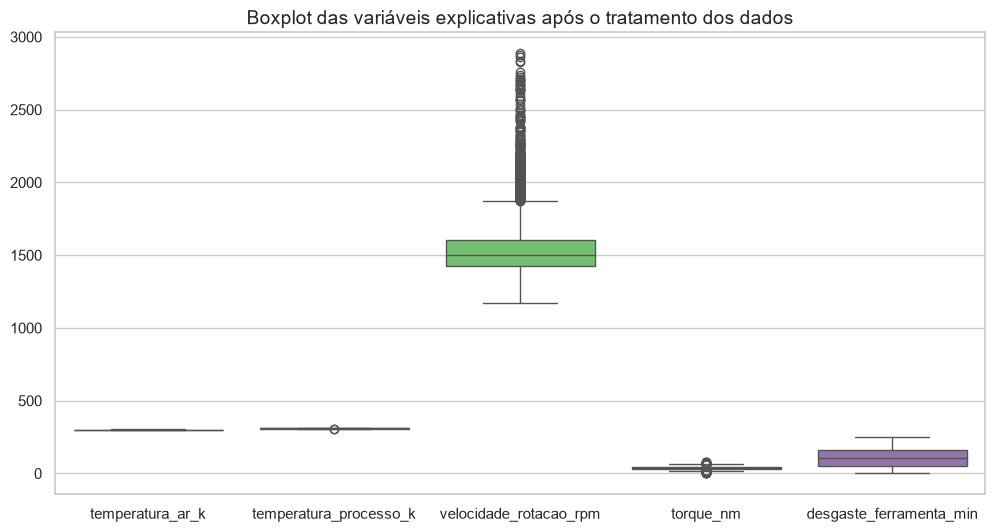

In [8]:
# Gerando o boxplot para identificar os outliers


# Para os gráficos serem salvos na pasta "outputs"

def salvar_grafico(nome_arquivo, etapa="02_data_prep", output_base_dir="../outputs/graficos"): # cria a subpasta para a etapa atual e exporta o gráfico gerado
    output_dir = os.path.join(output_base_dir, etapa)
    os.makedirs(output_dir, exist_ok=True) # cria o caminho dinâmico

    caminho_completo = os.path.join(output_dir, f"{nome_arquivo}.png") # define o caminho final do arquivo de imagem

    plt.savefig(caminho_completo, dpi=300, bbox_inches="tight")
    print(f"Grafico salvo em:{caminho_completo}") #salva o grafico atual

# Gerando o boxplot
variaveis_explicativas = ["temperatura_ar_k", "temperatura_processo_k", "velocidade_rotacao_rpm", "torque_nm","desgaste_ferramenta_min"]
plt.figure(figsize=(12,6))
sns.boxplot(data=df_tratado[variaveis_explicativas])
plt.title ("Boxplot das variáveis explicativas após o tratamento dos dados")
plt.xticks(rotation=0)
salvar_grafico("01_boxplot_todas")
plt.show()

Análise

O gráfico ficou com algumas variáveis mal representadas devido a diferença de escala. Para melhorar a visualização foram feitos gráficos separados para cada uma delas. 

Grafico salvo em:../outputs/graficos\02_data_prep\01_boxplot_isoladas.png


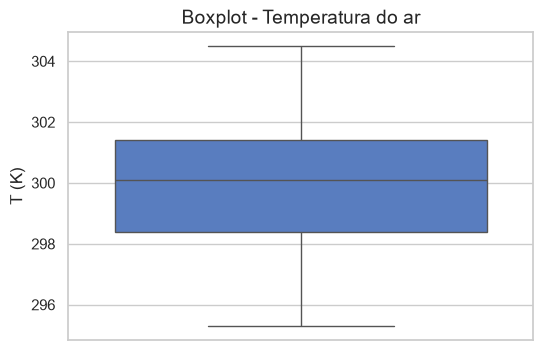

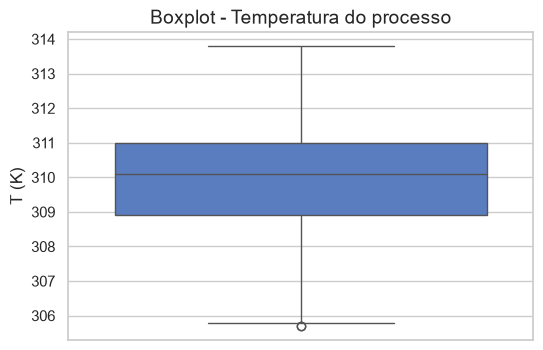

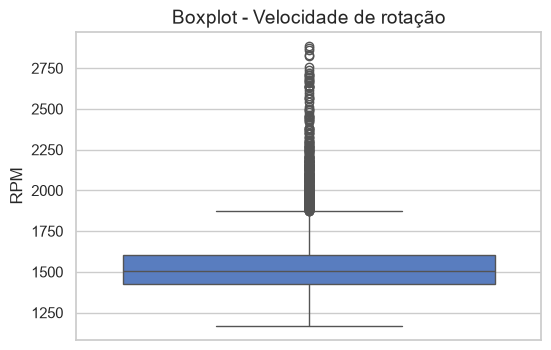

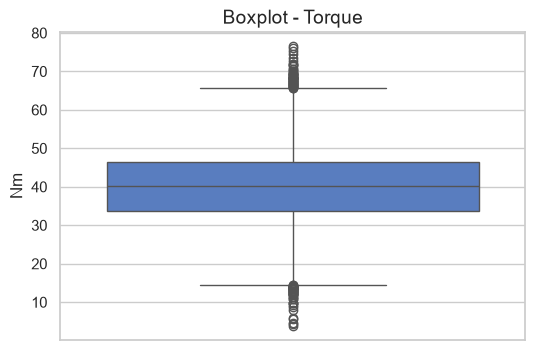

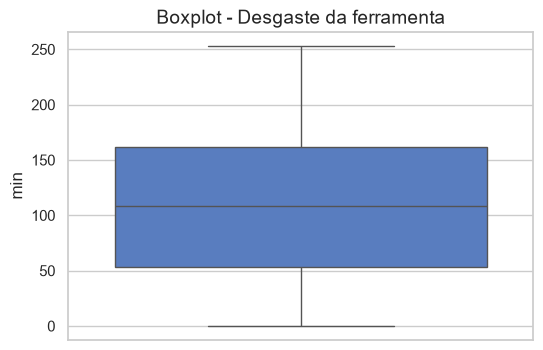

In [9]:
# Boxplot por variável explicativa

# Temperatura do ar
plt.figure(figsize=(6,4))
sns.boxplot(data=df_tratado["temperatura_ar_k"])
plt.title ("Boxplot - Temperatura do ar")
plt.ylabel("T (K)")

# Temperatura do processo
plt.figure(figsize=(6,4))
sns.boxplot(data=df_tratado["temperatura_processo_k"])
plt.title ("Boxplot - Temperatura do processo")
plt.ylabel("T (K)")

# Velocidade de rotação
plt.figure(figsize=(6,4))
sns.boxplot(data=df_tratado["velocidade_rotacao_rpm"])
plt.title ("Boxplot - Velocidade de rotação")
plt.ylabel("RPM")

# Torque
plt.figure(figsize=(6,4))
sns.boxplot(data=df_tratado["torque_nm"])
plt.title ("Boxplot - Torque")
plt.ylabel("Nm")

# Desgaste da ferramenta
plt.figure(figsize=(6,4))
sns.boxplot(data=df_tratado["desgaste_ferramenta_min"])
plt.title ("Boxplot - Desgaste da ferramenta")
plt.ylabel("min")


salvar_grafico("01_boxplot_isoladas")
plt.show()

Análise

Os outliers são representados pelos círculos localizados além dos limites. A variável velocidade de rotação e o torque apresentaram a maior concentração de outliers. Os outliers foram mantidos para as próximas análises.